# K0S momentum-scale DNN with parallel hyperparameter search

This notebook learns residual momentum-scale maps from the \(K^0_S\to\pi^+\pi^-\) mass constraint.

The workflow is:

1. load the candidate CSV;
2. keep both daughters of each pair together;
3. split by entry parity into training and untouched validation samples;
4. train side 0 and side 1 independently;
5. within one side, learn positive and negative scales jointly through
   \[
   \log s_q(p_T,\phi,\eta)=A(p_T,\phi,\eta)+qB(p_T,\phi,\eta);
   \]
6. search network, optimizer, scale-bound, and regularization parameters in parallel;
7. select parameters only from the validation half;
8. retrain an ensemble using the selected parameters;
9. write compatible positive/negative maps for both sides.

The grid-search workers use one PyTorch thread each. Set `requested_cpus = 12` or a larger value to run more trials concurrently.


In [1]:
# ============================================================
# Imports and CPU setup
# ============================================================

from pathlib import Path
from itertools import product
from array import array
import copy
import json
import math
import os
import random
import time
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

try:
    from joblib import Parallel, delayed, parallel_backend
    joblib_available = True
except ImportError:
    joblib_available = False
    print(
        "WARNING: joblib is not installed. "
        "The search will run sequentially."
    )

try:
    import ROOT as root
except ImportError:
    root = None

base_seed = 12345

random.seed(base_seed)
np.random.seed(base_seed)
torch.manual_seed(base_seed)

available_cpus = os.cpu_count() or 1

print("PyTorch:", torch.__version__)
print("Available CPUs:", available_cpus)
print("joblib available:", joblib_available)


Welcome to JupyROOT 6.30/06
PyTorch: 2.9.0+cu128
Available CPUs: 16
joblib available: True


In [ ]:
# ============================================================
# Main configuration
# ============================================================


csv_file = Path(
    "/media/yoren/T7_Shield/sPHENIX/tracking/csvs/fit_k0s_pp_v1.csv"
)

map_root_file = Path(
    "output/k0s_momentum_scale_map_plots_cut03/k0s_dnn_momentum_scale_map1.root"
)

map_csv_file = Path(
    "output/k0s_momentum_scale_map_plots_cut03/k0s_dnn_momentum_scale_grid.csv"
)

plot_dir = Path(
    "output/k0s_momentum_scale_map_plots_cut03"
)
plot_dir.mkdir(parents=True, exist_ok=True)


work_dir = Path(
    "distort/k0s_momentum_scale_map_plots_cut03"
)
work_dir.mkdir(parents=True, exist_ok=True)


grid_results_file = (
    work_dir / "grid_search_results.csv"
)

best_parameters_file = (
    work_dir / "best_hyperparameters.json"
)

checkpoint_dir = work_dir / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

selection_name = "cut03"

training_parity = 0
validation_parity = 1 - training_parity

pdg_kshort_mass = 0.497611
pion_mass = 0.13957039

fit_mass_minimum = 0.44
fit_mass_maximum = 0.56

fit_mass_minimum = 0.48
fit_mass_maximum = 0.52

# Fixed signal model used by every trial.
signal_fraction = 0.77
signal_sigma = 0.004

# Parallelism
requested_cpus = 12
threads_per_worker = 1

parallel_jobs = max(
    1,
    min(requested_cpus, available_cpus),
)

print("Parallel search workers:", parallel_jobs)

# Search behavior:
#   "random"    -> random subset of the Cartesian grid
#   "full_grid" -> every combination (can be extremely large)
search_mode = "random"
maximum_trials_per_side = 36
maximum_trials_per_side = 100

maximum_search_epochs = 300
search_patience = 35
search_patience = 40

# Final ensemble training after the search.
number_of_ensemble_models = 3
maximum_final_epochs = 1000
final_patience = 60

# Validation score:
#
# lower is better:
#   validation NLL
# + mean residual penalty
# + width-worsening penalty
# + map-boundary saturation penalty
score_mean_weight = 0.25
score_width_weight = 2.0
score_boundary_weight = 1.0

minimum_candidates_per_side_split = 1000


Parallel search workers: 12


## Hyperparameter search space

The full Cartesian product below is intentionally broad and may contain many thousands of combinations. The default `search_mode = "random"` draws a reproducible subset from this grid.

Set:

```python
search_mode = "full_grid"
```

only after reducing the lists to a manageable size.

The search varies:

- DNN width, depth, and dropout;
- batch size, learning rate, and weight decay;
- identity, smoothness, and charge-odd penalties;
- allowed charge-even, charge-odd, and total scale ranges.


In [ ]:
# ============================================================
# Search space
# ============================================================

search_space = {
    "hidden_width": [54, 16, 24, 32, 128],
    "hidden_layers": [3, 1, 2, 4],
    "dropout_probability": [0.05, 0.10, 0.01],
    "batch_size": [1024, 256, 512, 2048],
    "learning_rate": [2.0e-3, 3.0e-4, 1.0e-3, 4.e-3],
    "weight_decay": [2.0e-4, 1.0e-4, 5.0e-4],
    "identity_penalty": [20.0, 10.0, 50.0],
    "smoothness_penalty": [5.0, 2.0, 50.0],
    "odd_component_penalty": [2.0, 10.0, 1.0],
    "maximum_even_log_scale": [0.025, 0.015, 0.040],
    "maximum_odd_log_scale": [0.025, 0.015, 0.040],
    "maximum_total_log_scale": [0.045, 0.030, 0.070],
}

search_space = {
    "hidden_width": [54, 32, 128],
    "hidden_layers": [3, 2, 4],
    "dropout_probability": [0.05, 0.10, 0.01],
    "batch_size": [1024, 512, 2048],
    "learning_rate": [2.0e-3, 1.0e-3, 5.0e-3],
    "weight_decay": [2.0e-4, 1.0e-4, 5.0e-4],
    "identity_penalty": [20.0, 10.0, 50.0],
    "smoothness_penalty": [5.0, 2.0, 50.0],
    "odd_component_penalty": [2.0, 10.0, 1.0],
    "maximum_even_log_scale": [0.025, 0.015, 0.040],
    "maximum_odd_log_scale": [0.025, 0.015, 0.040],
    "maximum_total_log_scale": [0.045, 0.030, 0.070],
}


fixed_training_parameters = {
    "maximum_epochs": maximum_search_epochs,
    "patience": search_patience,
    "signal_fraction": signal_fraction,
    "signal_sigma": signal_sigma,
    "pdg_kshort_mass": pdg_kshort_mass,
    "pion_mass": pion_mass,
    "fit_mass_minimum": fit_mass_minimum,
    "fit_mass_maximum": fit_mass_maximum,
    "score_mean_weight": score_mean_weight,
    "score_width_weight": score_width_weight,
    "score_boundary_weight": score_boundary_weight,
}


## Load and select the CSV

Only same-side pairs are used in the first version. This permits one independent model per side while retaining the positive/negative coupling inside each \(K^0_S\) candidate.


In [4]:
# ============================================================
# Load and select candidates
# ============================================================

data = pd.read_csv(csv_file)

if selection_name == "cut03":
    selection_flag = data["pass_cut03"].astype(bool)
elif selection_name == "cut07":
    selection_flag = data["pass_cut07"].astype(bool)
else:
    raise ValueError(
        "selection_name must be 'cut03' or 'cut07'"
    )

selected = data.loc[
    selection_flag
    & data["pass_pion_pid"].astype(bool)
    & data["pass_signed_delta_phi"].astype(bool)
    & data["same_side"].astype(bool)
    & (data["mass_before"] >= fit_mass_minimum)
    & (data["mass_before"] <= fit_mass_maximum)
].copy()

selected["side"] = selected["side1"].astype(int)

print("CSV rows:", len(data))
print("Selected same-side rows:", len(selected))
print(selected.groupby(["side", "entry_parity"]).size())

for side in [0, 1]:
    for parity in [training_parity, validation_parity]:
        count = np.count_nonzero(
            (selected["side"] == side)
            & (selected["entry_parity"] == parity)
        )

        if count < minimum_candidates_per_side_split:
            raise RuntimeError(
                f"Only {count} candidates for side={side}, "
                f"parity={parity}. Increase the input sample."
            )


CSV rows: 1372721
Selected same-side rows: 21263
side  entry_parity
0     0               5790
      1               5629
1     0               4944
      1               4900
dtype: int64


In [5]:
# ============================================================
# Save compact side-specific NPZ files for worker processes
# ============================================================

def make_track_features(pt, phi, eta):
    return np.column_stack([
        np.log(np.clip(pt, 1.0e-4, None)),
        np.sin(phi),
        np.cos(phi),
        eta,
    ]).astype(np.float32)


side_npz_files = {}

for side in [0, 1]:
    frame = selected.loc[
        selected["side"] == side
    ].copy()

    output_file = work_dir / f"side{side}_pairs.npz"

    np.savez_compressed(
        output_file,
        features1=make_track_features(
            frame["pt1"].to_numpy(),
            frame["phi1"].to_numpy(),
            frame["eta1"].to_numpy(),
        ),
        features2=make_track_features(
            frame["pt2"].to_numpy(),
            frame["phi2"].to_numpy(),
            frame["eta2"].to_numpy(),
        ),
        charge1=frame["charge1"].to_numpy(
            dtype=np.float32
        ),
        charge2=frame["charge2"].to_numpy(
            dtype=np.float32
        ),
        momentum1=frame[
            ["px1", "py1", "pz1"]
        ].to_numpy(dtype=np.float32),
        momentum2=frame[
            ["px2", "py2", "pz2"]
        ].to_numpy(dtype=np.float32),
        mass_before=frame[
            "mass_before"
        ].to_numpy(dtype=np.float32),
        parity=frame[
            "entry_parity"
        ].to_numpy(dtype=np.int8),
    )

    side_npz_files[side] = output_file

    print(
        f"side {side}: wrote {len(frame):,} pairs to "
        f"{output_file}"
    )


side 0: wrote 11,419 pairs to distort/k0s_momentum_scale_map_plots_cut03/side0_pairs.npz
side 1: wrote 9,844 pairs to distort/k0s_momentum_scale_map_plots_cut03/side1_pairs.npz


In [6]:
# ============================================================
# Dataset, model, and physics functions
# ============================================================

class PairArrayDataset(Dataset):
    def __init__(self, arrays, indices):
        self.features1 = torch.from_numpy(
            arrays["features1"][indices]
        )
        self.features2 = torch.from_numpy(
            arrays["features2"][indices]
        )
        self.charge1 = torch.from_numpy(
            arrays["charge1"][indices]
        )
        self.charge2 = torch.from_numpy(
            arrays["charge2"][indices]
        )
        self.momentum1 = torch.from_numpy(
            arrays["momentum1"][indices]
        )
        self.momentum2 = torch.from_numpy(
            arrays["momentum2"][indices]
        )
        self.mass_before = torch.from_numpy(
            arrays["mass_before"][indices]
        )

    def __len__(self):
        return len(self.mass_before)

    def __getitem__(self, index):
        return {
            "features1": self.features1[index],
            "features2": self.features2[index],
            "charge1": self.charge1[index],
            "charge2": self.charge2[index],
            "momentum1": self.momentum1[index],
            "momentum2": self.momentum2[index],
            "mass_before": self.mass_before[index],
        }


class MomentumScaleNetwork(nn.Module):
    def __init__(self, configuration):
        super().__init__()

        hidden_width = int(
            configuration["hidden_width"]
        )
        hidden_layers = int(
            configuration["hidden_layers"]
        )
        dropout_probability = float(
            configuration["dropout_probability"]
        )

        layers = []
        current_width = 4

        for _ in range(hidden_layers):
            layers.extend([
                nn.Linear(
                    current_width,
                    hidden_width,
                ),
                nn.SiLU(),
                nn.Dropout(
                    dropout_probability
                ),
            ])

            current_width = hidden_width

        self.trunk = nn.Sequential(*layers)
        self.output = nn.Linear(current_width, 2)

        self.maximum_even_log_scale = float(
            configuration[
                "maximum_even_log_scale"
            ]
        )
        self.maximum_odd_log_scale = float(
            configuration[
                "maximum_odd_log_scale"
            ]
        )
        self.maximum_total_log_scale = float(
            configuration[
                "maximum_total_log_scale"
            ]
        )

        # Every trial starts exactly from scale = 1.
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def components(self, features):
        raw = self.output(
            self.trunk(features)
        )

        even_component = (
            self.maximum_even_log_scale
            * torch.tanh(raw[:, 0])
        )

        odd_component = (
            self.maximum_odd_log_scale
            * torch.tanh(raw[:, 1])
        )

        return even_component, odd_component

    def log_scale(self, features, charge):
        even_component, odd_component = (
            self.components(features)
        )

        combined = (
            even_component
            + charge * odd_component
        )

        return torch.clamp(
            combined,
            min=-self.maximum_total_log_scale,
            max=self.maximum_total_log_scale,
        )

    def scale(self, features, charge):
        return torch.exp(
            self.log_scale(
                features,
                charge,
            )
        )


def invariant_mass_torch(
    momentum1,
    momentum2,
    pion_mass_value,
):
    energy1 = torch.sqrt(
        torch.sum(
            momentum1 * momentum1,
            dim=1,
        )
        + pion_mass_value ** 2
    )

    energy2 = torch.sqrt(
        torch.sum(
            momentum2 * momentum2,
            dim=1,
        )
        + pion_mass_value ** 2
    )

    total = momentum1 + momentum2

    mass_squared = (
        (energy1 + energy2) ** 2
        - torch.sum(
            total * total,
            dim=1,
        )
    )

    return torch.sqrt(
        torch.clamp(
            mass_squared,
            min=0.0,
        )
    )


def mass_nll_torch(
    corrected_mass,
    configuration,
):
    signal_fraction_value = float(
        configuration["signal_fraction"]
    )

    signal_sigma_value = float(
        configuration["signal_sigma"]
    )

    pdg_mass_value = float(
        configuration["pdg_kshort_mass"]
    )

    gaussian = (
        1.0
        / (
            math.sqrt(2.0 * math.pi)
            * signal_sigma_value
        )
        * torch.exp(
            -0.5
            * (
                (
                    corrected_mass
                    - pdg_mass_value
                )
                / signal_sigma_value
            ) ** 2
        )
    )

    uniform = (
        1.0
        / (
            float(
                configuration[
                    "fit_mass_maximum"
                ]
            )
            - float(
                configuration[
                    "fit_mass_minimum"
                ]
            )
        )
    )

    probability = (
        signal_fraction_value * gaussian
        + (
            1.0 - signal_fraction_value
        ) * uniform
    )

    return -torch.log(
        torch.clamp(
            probability,
            min=1.0e-12,
        )
    ).mean()


def perturb_features(features):
    perturbed = features.clone()
    noise = torch.randn_like(perturbed)

    perturbed[:, 0] += (
        0.025 * noise[:, 0]
    )
    perturbed[:, 1] += (
        0.025 * noise[:, 1]
    )
    perturbed[:, 2] += (
        0.025 * noise[:, 2]
    )
    perturbed[:, 3] += (
        0.025 * noise[:, 3]
    )

    return perturbed


In [7]:
# ============================================================
# Training and validation functions
# ============================================================

def configure_worker_threads(
    threads=1,
):
    os.environ["OMP_NUM_THREADS"] = str(threads)
    os.environ["MKL_NUM_THREADS"] = str(threads)
    os.environ["OPENBLAS_NUM_THREADS"] = str(threads)
    os.environ["NUMEXPR_NUM_THREADS"] = str(threads)

    torch.set_num_threads(threads)

    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        # A reused worker process may already have initialized
        # its inter-op thread pool.
        pass


def calculate_training_loss(
    model,
    batch,
    configuration,
):
    features1 = batch["features1"]
    features2 = batch["features2"]

    charge1 = batch["charge1"]
    charge2 = batch["charge2"]

    momentum1 = batch["momentum1"]
    momentum2 = batch["momentum2"]

    log_scale1 = model.log_scale(
        features1,
        charge1,
    )

    log_scale2 = model.log_scale(
        features2,
        charge2,
    )

    corrected_momentum1 = (
        torch.exp(log_scale1)[:, None]
        * momentum1
    )

    corrected_momentum2 = (
        torch.exp(log_scale2)[:, None]
        * momentum2
    )

    corrected_mass = invariant_mass_torch(
        corrected_momentum1,
        corrected_momentum2,
        float(configuration["pion_mass"]),
    )

    likelihood_loss = mass_nll_torch(
        corrected_mass,
        configuration,
    )

    identity_loss = (
        torch.mean(log_scale1 ** 2)
        + torch.mean(log_scale2 ** 2)
    )

    _, odd1 = model.components(features1)
    _, odd2 = model.components(features2)

    odd_loss = (
        torch.mean(odd1 ** 2)
        + torch.mean(odd2 ** 2)
    )

    perturbed1 = perturb_features(features1)
    perturbed2 = perturb_features(features2)

    smoothness_loss = (
        torch.mean(
            (
                model.log_scale(
                    perturbed1,
                    charge1,
                )
                - log_scale1
            ) ** 2
        )
        + torch.mean(
            (
                model.log_scale(
                    perturbed2,
                    charge2,
                )
                - log_scale2
            ) ** 2
        )
    )

    total_loss = (
        likelihood_loss
        + float(
            configuration[
                "identity_penalty"
            ]
        ) * identity_loss
        + float(
            configuration[
                "odd_component_penalty"
            ]
        ) * odd_loss
        + float(
            configuration[
                "smoothness_penalty"
            ]
        ) * smoothness_loss
    )

    return total_loss


def numpy_mass_metrics(values):
    values = np.asarray(values)

    signal_window = values[
        (values >= 0.47)
        & (values <= 0.53)
    ]

    if len(signal_window) < 2:
        return {
            "mean": np.nan,
            "width": np.nan,
            "entries": len(signal_window),
        }

    return {
        "mean": float(
            np.mean(signal_window)
        ),
        "width": float(
            np.std(
                signal_window,
                ddof=1,
            )
        ),
        "entries": int(
            len(signal_window)
        ),
    }


def numpy_mass_nll(
    values,
    configuration,
):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    fraction = float(
        configuration["signal_fraction"]
    )

    sigma = float(
        configuration["signal_sigma"]
    )

    pdg_mass = float(
        configuration["pdg_kshort_mass"]
    )

    gaussian = (
        1.0
        / (
            math.sqrt(2.0 * math.pi)
            * sigma
        )
        * np.exp(
            -0.5
            * (
                (values - pdg_mass)
                / sigma
            ) ** 2
        )
    )

    uniform = (
        1.0
        / (
            float(
                configuration[
                    "fit_mass_maximum"
                ]
            )
            - float(
                configuration[
                    "fit_mass_minimum"
                ]
            )
        )
    )

    probability = (
        fraction * gaussian
        + (1.0 - fraction) * uniform
    )

    return float(
        -np.mean(
            np.log(
                np.clip(
                    probability,
                    1.0e-12,
                    None,
                )
            )
        )
    )


@torch.no_grad()
def evaluate_loader(
    model,
    loader,
    configuration,
):
    model.eval()

    original_masses = []
    corrected_masses = []
    absolute_log_scales = []

    for batch in loader:
        features1 = batch["features1"]
        features2 = batch["features2"]

        charge1 = batch["charge1"]
        charge2 = batch["charge2"]

        momentum1 = batch["momentum1"]
        momentum2 = batch["momentum2"]

        log_scale1 = model.log_scale(
            features1,
            charge1,
        )

        log_scale2 = model.log_scale(
            features2,
            charge2,
        )

        corrected_mass = invariant_mass_torch(
            torch.exp(log_scale1)[:, None]
            * momentum1,
            torch.exp(log_scale2)[:, None]
            * momentum2,
            float(configuration["pion_mass"]),
        )

        original_masses.append(
            batch["mass_before"].numpy()
        )

        corrected_masses.append(
            corrected_mass.numpy()
        )

        absolute_log_scales.append(
            torch.cat([
                torch.abs(log_scale1),
                torch.abs(log_scale2),
            ]).numpy()
        )

    original_masses = np.concatenate(
        original_masses
    )

    corrected_masses = np.concatenate(
        corrected_masses
    )

    absolute_log_scales = np.concatenate(
        absolute_log_scales
    )

    before_metrics = numpy_mass_metrics(
        original_masses
    )

    after_metrics = numpy_mass_metrics(
        corrected_masses
    )

    validation_nll = numpy_mass_nll(
        corrected_masses,
        configuration,
    )

    mean_pull = (
        abs(
            after_metrics["mean"]
            - float(
                configuration[
                    "pdg_kshort_mass"
                ]
            )
        )
        / 0.001
        if np.isfinite(
            after_metrics["mean"]
        )
        else 1.0e6
    )

    width_ratio = (
        after_metrics["width"]
        / before_metrics["width"]
        if (
            np.isfinite(
                after_metrics["width"]
            )
            and np.isfinite(
                before_metrics["width"]
            )
            and before_metrics["width"] > 0
        )
        else 1.0e6
    )

    maximum_total = float(
        configuration[
            "maximum_total_log_scale"
        ]
    )

    boundary_fraction = float(
        np.mean(
            absolute_log_scales
            >= 0.90 * maximum_total
        )
    )

    score = (
        validation_nll
        + float(
            configuration[
                "score_mean_weight"
            ]
        ) * mean_pull
        + float(
            configuration[
                "score_width_weight"
            ]
        ) * max(
            0.0,
            width_ratio - 1.0,
        )
        + float(
            configuration[
                "score_boundary_weight"
            ]
        ) * boundary_fraction
    )

    return {
        "score": float(score),
        "validation_nll": validation_nll,
        "mean_before": before_metrics["mean"],
        "mean_after": after_metrics["mean"],
        "width_before": before_metrics["width"],
        "width_after": after_metrics["width"],
        "width_ratio": float(width_ratio),
        "boundary_fraction": boundary_fraction,
        "mass_before": original_masses,
        "mass_after": corrected_masses,
    }


def train_model_from_npz(
    npz_file,
    configuration,
    random_seed,
    save_checkpoint=None,
):
    configure_worker_threads(
        threads_per_worker
    )

    random.seed(random_seed)
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)

    arrays = np.load(npz_file)

    training_indices = np.flatnonzero(
        arrays["parity"]
        == training_parity
    )

    validation_indices = np.flatnonzero(
        arrays["parity"]
        == validation_parity
    )

    training_dataset = PairArrayDataset(
        arrays,
        training_indices,
    )

    validation_dataset = PairArrayDataset(
        arrays,
        validation_indices,
    )

    batch_size_value = int(
        configuration["batch_size"]
    )

    training_loader = DataLoader(
        training_dataset,
        batch_size=min(
            batch_size_value,
            len(training_dataset),
        ),
        shuffle=True,
        drop_last=False,
        num_workers=0,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=min(
            max(batch_size_value, 512),
            len(validation_dataset),
        ),
        shuffle=False,
        drop_last=False,
        num_workers=0,
    )

    model = MomentumScaleNetwork(
        configuration
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(
            configuration[
                "learning_rate"
            ]
        ),
        weight_decay=float(
            configuration[
                "weight_decay"
            ]
        ),
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=max(
                5,
                int(
                    configuration[
                        "patience"
                    ]
                ) // 4,
            ),
            min_lr=1.0e-5,
        )
    )

    best_state = copy.deepcopy(
        model.state_dict()
    )

    best_evaluation = None
    best_score = np.inf
    best_epoch = -1
    epochs_without_improvement = 0

    maximum_epochs_value = int(
        configuration[
            "maximum_epochs"
        ]
    )

    patience_value = int(
        configuration["patience"]
    )

    for epoch in range(
        maximum_epochs_value
    ):
        model.train()

        for batch in training_loader:
            optimizer.zero_grad()

            loss = calculate_training_loss(
                model,
                batch,
                configuration,
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )

            optimizer.step()

        evaluation = evaluate_loader(
            model,
            validation_loader,
            configuration,
        )

        scheduler.step(
            evaluation["score"]
        )

        if (
            evaluation["score"]
            < best_score - 1.0e-5
        ):
            best_score = (
                evaluation["score"]
            )
            best_evaluation = evaluation
            best_state = copy.deepcopy(
                model.state_dict()
            )
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= patience_value
        ):
            break

    model.load_state_dict(best_state)

    final_evaluation = evaluate_loader(
        model,
        validation_loader,
        configuration,
    )

    if save_checkpoint is not None:
        torch.save(
            {
                "state_dict": model.state_dict(),
                "configuration": configuration,
                "random_seed": random_seed,
                "best_epoch": best_epoch,
                "validation": {
                    key: value
                    for key, value
                    in final_evaluation.items()
                    if key
                    not in {
                        "mass_before",
                        "mass_after",
                    }
                },
            },
            save_checkpoint,
        )

    return {
        "score": final_evaluation["score"],
        "validation_nll": final_evaluation[
            "validation_nll"
        ],
        "mean_before": final_evaluation[
            "mean_before"
        ],
        "mean_after": final_evaluation[
            "mean_after"
        ],
        "width_before": final_evaluation[
            "width_before"
        ],
        "width_after": final_evaluation[
            "width_after"
        ],
        "width_ratio": final_evaluation[
            "width_ratio"
        ],
        "boundary_fraction": final_evaluation[
            "boundary_fraction"
        ],
        "best_epoch": best_epoch,
    }


In [8]:
# ============================================================
# Construct a reproducible search list
# ============================================================

def cartesian_configurations(space):
    keys = list(space)

    for values in product(
        *[space[key] for key in keys]
    ):
        yield dict(zip(keys, values))


all_configurations = list(
    cartesian_configurations(
        search_space
    )
)

print(
    "Full Cartesian grid size:",
    len(all_configurations),
)

if search_mode == "full_grid":
    selected_configurations = (
        all_configurations
    )
elif search_mode == "random":
    rng = np.random.default_rng(
        base_seed
    )

    count = min(
        maximum_trials_per_side,
        len(all_configurations),
    )

    selected_indices = rng.choice(
        len(all_configurations),
        size=count,
        replace=False,
    )

    selected_configurations = [
        all_configurations[index]
        for index in selected_indices
    ]
else:
    raise ValueError(
        "search_mode must be "
        "'random' or 'full_grid'"
    )

for trial_id, configuration in enumerate(
    selected_configurations
):
    configuration["trial_id"] = trial_id
    configuration.update(
        fixed_training_parameters
    )

print(
    "Configurations per side:",
    len(selected_configurations),
)
print(
    "Total side-specific trials:",
    2 * len(selected_configurations),
)


Full Cartesian grid size: 2099520
Configurations per side: 900
Total side-specific trials: 1800


In [9]:
# ============================================================
# Parallel grid-search worker
# ============================================================

def run_search_trial(
    side,
    configuration,
):
    started = time.time()

    trial_id = int(
        configuration["trial_id"]
    )

    random_seed = (
        base_seed
        + 100000 * side
        + trial_id
    )

    try:
        metrics = train_model_from_npz(
            npz_file=str(
                side_npz_files[side]
            ),
            configuration=configuration,
            random_seed=random_seed,
        )

        result = {
            "success": True,
            "side": side,
            "trial_id": trial_id,
            "random_seed": random_seed,
            "elapsed_seconds": (
                time.time() - started
            ),
            **{
                key: value
                for key, value
                in configuration.items()
                if key
                not in {
                    "signal_fraction",
                    "signal_sigma",
                    "pdg_kshort_mass",
                    "pion_mass",
                    "fit_mass_minimum",
                    "fit_mass_maximum",
                    "score_mean_weight",
                    "score_width_weight",
                    "score_boundary_weight",
                }
            },
            **metrics,
        }

        return result

    except Exception as error:
        return {
            "success": False,
            "side": side,
            "trial_id": trial_id,
            "random_seed": random_seed,
            "elapsed_seconds": (
                time.time() - started
            ),
            "error": repr(error),
            "traceback": traceback.format_exc(),
        }


search_tasks = [
    (side, configuration)
    for side in [0, 1]
    for configuration in selected_configurations
]

print(
    f"Launching {len(search_tasks)} trials "
    f"with {parallel_jobs} workers"
)

if joblib_available and parallel_jobs > 1:
    with parallel_backend(
        "loky",
        inner_max_num_threads=threads_per_worker,
    ):
        search_results = Parallel(
            n_jobs=parallel_jobs,
            verbose=10,
            batch_size=1,
        )(
            delayed(run_search_trial)(
                side,
                configuration,
            )
            for side, configuration
            in search_tasks
        )
else:
    search_results = [
        run_search_trial(
            side,
            configuration,
        )
        for side, configuration
        in search_tasks
    ]

print("Search finished")


Launching 1800 trials with 12 workers


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:   12.1s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:   27.0s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:   58.0s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:  1.3min
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:  1.9min
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:  2.4min
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:  2.9min
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:  3.5min
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:  4.2min
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:  4.9min
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:  5.8min
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:  6.4min
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:  7.3min
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:  8.2min
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed:  

Search finished


[Parallel(n_jobs=12)]: Done 1800 out of 1800 | elapsed: 87.8min finished


In [10]:
# ============================================================
# Search results
# ============================================================

search_results_frame = pd.DataFrame(
    search_results
)

search_results_frame.to_csv(
    grid_results_file,
    index=False,
)

failed = search_results_frame.loc[
    ~search_results_frame[
        "success"
    ].astype(bool)
]

successful = search_results_frame.loc[
    search_results_frame[
        "success"
    ].astype(bool)
].copy()

print("Successful trials:", len(successful))
print("Failed trials:", len(failed))
print("Wrote:", grid_results_file)

if len(failed):
    display(
        failed[
            [
                "side",
                "trial_id",
                "error",
            ]
        ]
    )

for side in [0, 1]:
    print(f"\nTop side {side} trials:")

    display(
        successful.loc[
            successful["side"] == side
        ]
        .sort_values("score")
        .head(10)
        [
            [
                "trial_id",
                "score",
                "validation_nll",
                "mean_after",
                "width_ratio",
                "boundary_fraction",
                "hidden_width",
                "hidden_layers",
                "dropout_probability",
                "batch_size",
                "learning_rate",
                "weight_decay",
                "identity_penalty",
                "smoothness_penalty",
                "odd_component_penalty",
                "maximum_even_log_scale",
                "maximum_odd_log_scale",
                "maximum_total_log_scale",
                "best_epoch",
                "elapsed_seconds",
            ]
        ]
    )


Successful trials: 1800
Failed trials: 0
Wrote: distort/k0s_momentum_scale_map_plots_cut03/grid_search_results.csv

Top side 0 trials:


,trial_id,score,validation_nll,mean_after,width_ratio,boundary_fraction,hidden_width,hidden_layers,dropout_probability,batch_size,learning_rate,weight_decay,identity_penalty,smoothness_penalty,odd_component_penalty,maximum_even_log_scale,maximum_odd_log_scale,maximum_total_log_scale,best_epoch,elapsed_seconds
558,558,-3.283321,-3.283620,0.497611,0.971236,0.000266,128,4,0.01,1024,0.004,0.0002,20.0,2.0,1.0,0.04,0.040,0.07,52,54.473445
822,822,-3.283261,-3.283660,0.497613,0.969523,0.000000,128,4,0.10,256,0.004,0.0002,20.0,50.0,10.0,0.04,0.025,0.07,59,172.147329
327,327,-3.279203,-3.279446,0.497612,0.967101,0.000000,128,4,0.05,256,0.002,0.0001,50.0,50.0,10.0,0.04,0.025,0.07,119,107.161939
626,626,-3.275463,-3.275956,0.497611,0.969760,0.000444,54,4,0.05,512,0.002,0.0001,20.0,2.0,10.0,0.04,0.040,0.07,212,230.157788
394,394,-3.271100,-3.275351,0.497603,0.975160,0.002132,54,3,0.05,1024,0.004,0.0002,10.0,5.0,2.0,0.04,0.040,0.07,89,64.694181
59,59,-3.269595,-3.270206,0.497611,0.971040,0.000533,54,3,0.05,1024,0.002,0.0001,20.0,50.0,2.0,0.04,0.040,0.07,122,48.230121
139,139,-3.269278,-3.270422,0.497611,0.967299,0.001066,54,3,0.01,256,0.002,0.0005,50.0,5.0,10.0,0.04,0.025,0.07,69,60.998659
204,204,-3.269132,-3.270640,0.497617,0.965167,0.000089,128,3,0.01,256,0.002,0.0001,50.0,50.0,10.0,0.04,0.025,0.07,43,67.445542
410,410,-3.268282,-3.269204,0.497610,0.972612,0.000711,128,3,0.05,512,0.002,0.0002,10.0,50.0,1.0,0.04,0.025,0.07,92,141.656440
363,363,-3.267162,-3.268292,0.497610,0.974747,0.000888,32,4,0.01,256,0.002,0.0005,20.0,50.0,1.0,0.04,0.040,0.07,128,100.124410



Top side 1 trials:


,trial_id,score,validation_nll,mean_after,width_ratio,boundary_fraction,hidden_width,hidden_layers,dropout_probability,batch_size,learning_rate,weight_decay,identity_penalty,smoothness_penalty,odd_component_penalty,maximum_even_log_scale,maximum_odd_log_scale,maximum_total_log_scale,best_epoch,elapsed_seconds
1104,204,-3.282577,-3.282840,0.497612,0.956960,0.000102,128,3,0.01,256,0.002,0.0001,50.0,50.0,10.0,0.040,0.025,0.07,109,67.905587
1227,327,-3.282394,-3.282961,0.497611,0.955974,0.000510,128,4,0.05,256,0.002,0.0001,50.0,50.0,10.0,0.040,0.025,0.07,82,104.876239
1019,119,-3.282022,-3.287487,0.497608,0.961474,0.004694,128,3,0.10,256,0.002,0.0002,10.0,50.0,10.0,0.025,0.040,0.07,91,61.335716
1722,822,-3.280382,-3.285382,0.497617,0.961808,0.003469,128,4,0.10,256,0.004,0.0002,20.0,50.0,10.0,0.040,0.025,0.07,44,89.693077
1039,139,-3.279275,-3.279768,0.497613,0.957206,0.000102,54,3,0.01,256,0.002,0.0005,50.0,5.0,10.0,0.040,0.025,0.07,142,72.136585
1165,265,-3.277357,-3.284140,0.497611,0.957236,0.006735,128,3,0.01,1024,0.002,0.0002,50.0,2.0,1.0,0.040,0.040,0.07,134,69.645087
1717,817,-3.274418,-3.274460,0.497611,0.958590,0.000000,24,2,0.01,256,0.004,0.0001,50.0,2.0,2.0,0.040,0.025,0.07,161,65.669441
923,23,-3.274122,-3.274385,0.497612,0.961756,0.000102,24,3,0.10,512,0.004,0.0001,20.0,2.0,1.0,0.040,0.025,0.07,57,55.613150
1526,626,-3.273398,-3.289335,0.497602,0.962565,0.013571,54,4,0.05,512,0.002,0.0001,20.0,2.0,10.0,0.040,0.040,0.07,121,72.295260
1794,894,-3.273235,-3.274155,0.497607,0.961614,0.000000,54,2,0.10,1024,0.004,0.0001,20.0,50.0,2.0,0.025,0.025,0.07,99,52.421336


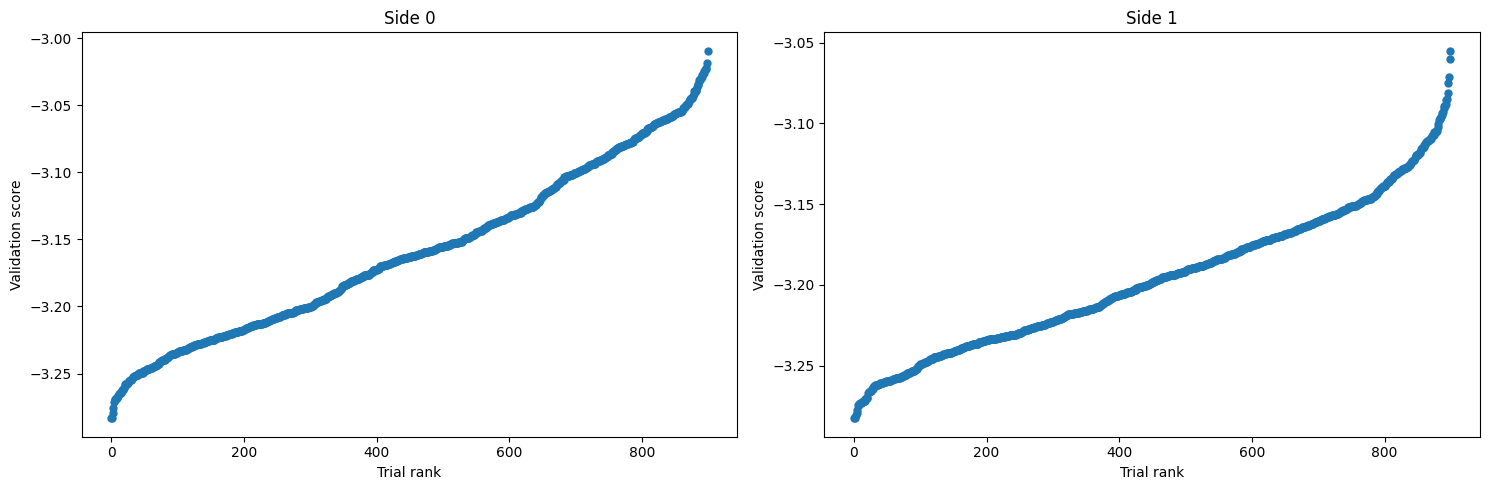

In [11]:
# ============================================================
# Search-result plots
# ============================================================

figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

for side in [0, 1]:
    side_results = successful.loc[
        successful["side"] == side
    ].sort_values("score")

    axes[side].scatter(
        np.arange(len(side_results)),
        side_results["score"],
        s=25,
    )

    axes[side].set_xlabel(
        "Trial rank"
    )
    axes[side].set_ylabel(
        "Validation score"
    )
    axes[side].set_title(
        f"Side {side}"
    )

figure.tight_layout()
plt.show()


In [12]:
# ============================================================
# Select the best configuration independently for each side
# ============================================================

best_configurations = {}

for side in [0, 1]:
    side_results = successful.loc[
        successful["side"] == side
    ].sort_values("score")

    if len(side_results) == 0:
        raise RuntimeError(
            f"No successful trials for side {side}"
        )

    best_row = side_results.iloc[0]

    trial_id = int(
        best_row["trial_id"]
    )

    configuration = copy.deepcopy(
        selected_configurations[
            trial_id
        ]
    )

    configuration["maximum_epochs"] = (
        maximum_final_epochs
    )
    configuration["patience"] = (
        final_patience
    )

    best_configurations[side] = (
        configuration
    )

    print(
        f"side {side}: best trial {trial_id}, "
        f"score={best_row['score']:.6f}"
    )

with open(
    best_parameters_file,
    "w",
) as output:
    json.dump(
        {
            str(side): configuration
            for side, configuration
            in best_configurations.items()
        },
        output,
        indent=2,
    )

print("Wrote:", best_parameters_file)


side 0: best trial 558, score=-3.283321
side 1: best trial 204, score=-3.282577
Wrote: distort/k0s_momentum_scale_map_plots_cut03/best_hyperparameters.json


## Retrain the final ensemble

Each side uses its own selected hyperparameters. Ensemble members differ only by random seed and are trained in parallel.

The final map is the average prediction of the ensemble. The model-to-model spread is also written to the map CSV as a stability estimate.


In [13]:
# ============================================================
# Parallel final-ensemble training
# ============================================================

def train_final_member(
    side,
    ensemble_index,
):
    configuration = copy.deepcopy(
        best_configurations[side]
    )

    random_seed = (
        base_seed
        + 1_000_000
        + 10_000 * side
        + ensemble_index
    )

    checkpoint = (
        checkpoint_dir
        / (
            f"side{side}_"
            f"ensemble{ensemble_index}.pt"
        )
    )

    metrics = train_model_from_npz(
        npz_file=str(
            side_npz_files[side]
        ),
        configuration=configuration,
        random_seed=random_seed,
        save_checkpoint=str(checkpoint),
    )

    return {
        "side": side,
        "ensemble_index": ensemble_index,
        "random_seed": random_seed,
        "checkpoint": str(checkpoint),
        **metrics,
    }


final_tasks = [
    (side, ensemble_index)
    for side in [0, 1]
    for ensemble_index in range(
        number_of_ensemble_models
    )
]

if joblib_available and parallel_jobs > 1:
    with parallel_backend(
        "loky",
        inner_max_num_threads=threads_per_worker,
    ):
        final_results = Parallel(
            n_jobs=min(
                parallel_jobs,
                len(final_tasks),
            ),
            verbose=10,
            batch_size=1,
        )(
            delayed(train_final_member)(
                side,
                ensemble_index,
            )
            for side, ensemble_index
            in final_tasks
        )
else:
    final_results = [
        train_final_member(
            side,
            ensemble_index,
        )
        for side, ensemble_index
        in final_tasks
    ]

final_results_frame = pd.DataFrame(
    final_results
)

display(final_results_frame)


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:  1.0min remaining:  2.0min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:  1.1min remaining:  1.1min
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:  1.2min remaining:   37.0s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:  1.6min finished


,side,ensemble_index,random_seed,checkpoint,score,validation_nll,mean_before,mean_after,width_before,width_after,width_ratio,boundary_fraction,best_epoch
0,0,0,1012345,distort/k0s_momentum_scale_map_plots_cut03/che...,-3.278374,-3.284997,0.499709,0.497587,0.009119,0.008872,0.972867,0.000622,42
1,0,1,1012346,distort/k0s_momentum_scale_map_plots_cut03/che...,-3.280648,-3.282084,0.499709,0.497613,0.009119,0.008930,0.979307,0.000888,141
2,0,2,1012347,distort/k0s_momentum_scale_map_plots_cut03/che...,-3.280267,-3.286187,0.499709,0.497630,0.009119,0.008876,0.973354,0.001155,46
3,1,0,1022345,distort/k0s_momentum_scale_map_plots_cut03/che...,-3.278872,-3.281556,0.499316,0.497612,0.009117,0.008729,0.957506,0.002449,121
4,1,1,1022346,distort/k0s_momentum_scale_map_plots_cut03/che...,-3.283312,-3.285130,0.499316,0.497615,0.009117,0.008726,0.957103,0.000816,89
5,1,2,1022347,distort/k0s_momentum_scale_map_plots_cut03/che...,-3.279856,-3.282348,0.499316,0.497612,0.009117,0.008772,0.962165,0.002347,121


In [14]:
# ============================================================
# Load final ensemble models
# ============================================================

ensemble_models = {
    0: [],
    1: [],
}

for result in final_results:
    side = int(result["side"])

    checkpoint = torch.load(
        result["checkpoint"],
        map_location="cpu",
    )

    model = MomentumScaleNetwork(
        checkpoint["configuration"]
    )

    model.load_state_dict(
        checkpoint["state_dict"]
    )

    model.eval()

    ensemble_models[side].append(
        model
    )


@torch.no_grad()
def ensemble_scale_statistics(
    side,
    charge,
    pt,
    phi,
    eta,
):
    pt = np.asarray(
        pt,
        dtype=np.float32,
    )

    phi = np.asarray(
        phi,
        dtype=np.float32,
    )

    eta = np.asarray(
        eta,
        dtype=np.float32,
    )

    charge = np.asarray(
        charge,
        dtype=np.float32,
    )

    features = torch.from_numpy(
        make_track_features(
            pt,
            phi,
            eta,
        )
    )

    charge_tensor = torch.from_numpy(
        charge
    )

    predictions = []

    for model in ensemble_models[side]:
        predictions.append(
            model.scale(
                features,
                charge_tensor,
            ).numpy()
        )

    predictions = np.stack(
        predictions,
        axis=0,
    )

    return {
        "mean": np.mean(
            predictions,
            axis=0,
        ),
        "std": np.std(
            predictions,
            axis=0,
            ddof=1,
        )
        if predictions.shape[0] > 1
        else np.zeros_like(
            predictions[0]
        ),
        "all": predictions,
    }


side 0 before: {'mean': 0.49970934027089897, 'width': 0.009118980146983651, 'entries': 5629}
side 0 after: {'mean': 0.4976134858932791, 'width': 0.008864693059520428, 'entries': 5623}
side 1 before: {'mean': 0.49931598702215707, 'width': 0.009116814817009036, 'entries': 4900}
side 1 after: {'mean': 0.49761299037614437, 'width': 0.008725350555356627, 'entries': 4898}


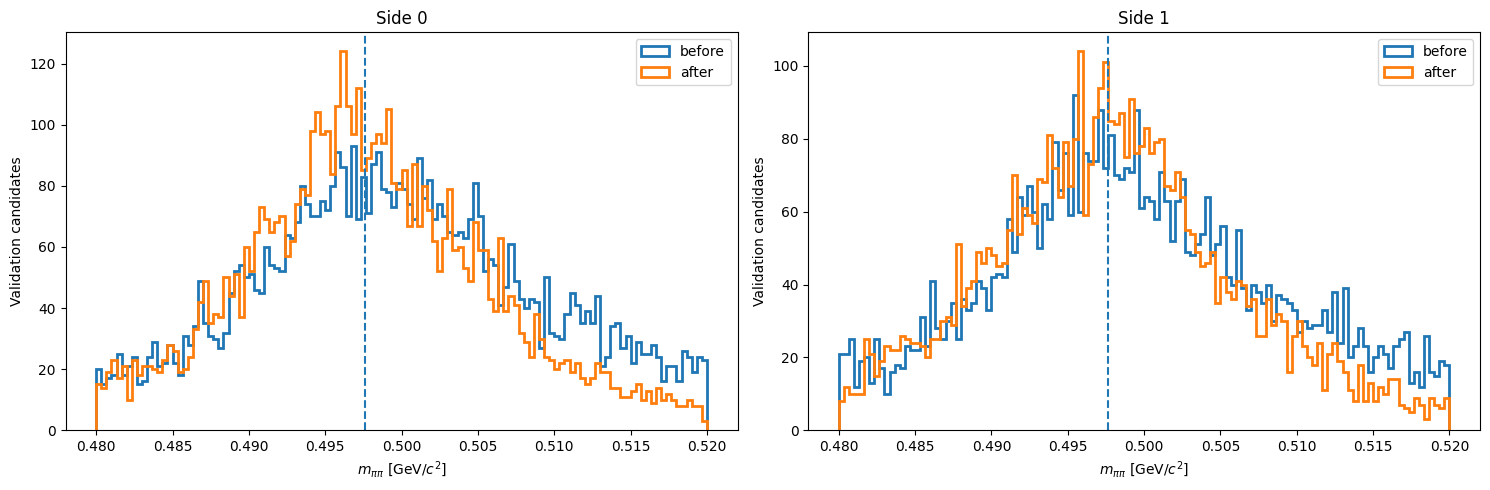

In [15]:
# ============================================================
# Independent validation mass with the final ensemble
# ============================================================

def corrected_mass_numpy(
    frame,
    side,
):
    scale1 = ensemble_scale_statistics(
        side=side,
        charge=frame[
            "charge1"
        ].to_numpy(),
        pt=frame["pt1"].to_numpy(),
        phi=frame["phi1"].to_numpy(),
        eta=frame["eta1"].to_numpy(),
    )["mean"]

    scale2 = ensemble_scale_statistics(
        side=side,
        charge=frame[
            "charge2"
        ].to_numpy(),
        pt=frame["pt2"].to_numpy(),
        phi=frame["phi2"].to_numpy(),
        eta=frame["eta2"].to_numpy(),
    )["mean"]

    momentum1 = frame[
        ["px1", "py1", "pz1"]
    ].to_numpy(dtype=np.float64)

    momentum2 = frame[
        ["px2", "py2", "pz2"]
    ].to_numpy(dtype=np.float64)

    momentum1 *= scale1[:, None]
    momentum2 *= scale2[:, None]

    energy1 = np.sqrt(
        np.sum(
            momentum1 ** 2,
            axis=1,
        )
        + pion_mass ** 2
    )

    energy2 = np.sqrt(
        np.sum(
            momentum2 ** 2,
            axis=1,
        )
        + pion_mass ** 2
    )

    total = momentum1 + momentum2

    mass_squared = (
        (energy1 + energy2) ** 2
        - np.sum(
            total ** 2,
            axis=1,
        )
    )

    return np.sqrt(
        np.clip(
            mass_squared,
            0.0,
            None,
        )
    )


validation_outputs = {}

figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

for side in [0, 1]:
    frame = selected.loc[
        (selected["side"] == side)
        & (
            selected["entry_parity"]
            == validation_parity
        )
    ].copy()

    mass_before = frame[
        "mass_before"
    ].to_numpy()

    mass_after = corrected_mass_numpy(
        frame,
        side,
    )

    validation_outputs[side] = {
        "frame": frame,
        "mass_before": mass_before,
        "mass_after": mass_after,
    }

    print(
        f"side {side} before:",
        numpy_mass_metrics(
            mass_before
        ),
    )

    print(
        f"side {side} after:",
        numpy_mass_metrics(
            mass_after
        ),
    )

    axes[side].hist(
        mass_before,
        bins=120,
        range=(
            fit_mass_minimum,
            fit_mass_maximum,
        ),
        histtype="step",
        linewidth=2,
        label="before",
    )

    axes[side].hist(
        mass_after,
        bins=120,
        range=(
            fit_mass_minimum,
            fit_mass_maximum,
        ),
        histtype="step",
        linewidth=2,
        label="after",
    )

    axes[side].axvline(
        pdg_kshort_mass,
        linestyle="--",
    )

    axes[side].set_xlabel(
        r"$m_{\pi\pi}$ [GeV/$c^2$]"
    )
    axes[side].set_ylabel(
        "Validation candidates"
    )
    axes[side].set_title(
        f"Side {side}"
    )
    axes[side].legend()

figure.tight_layout()
plt.show()


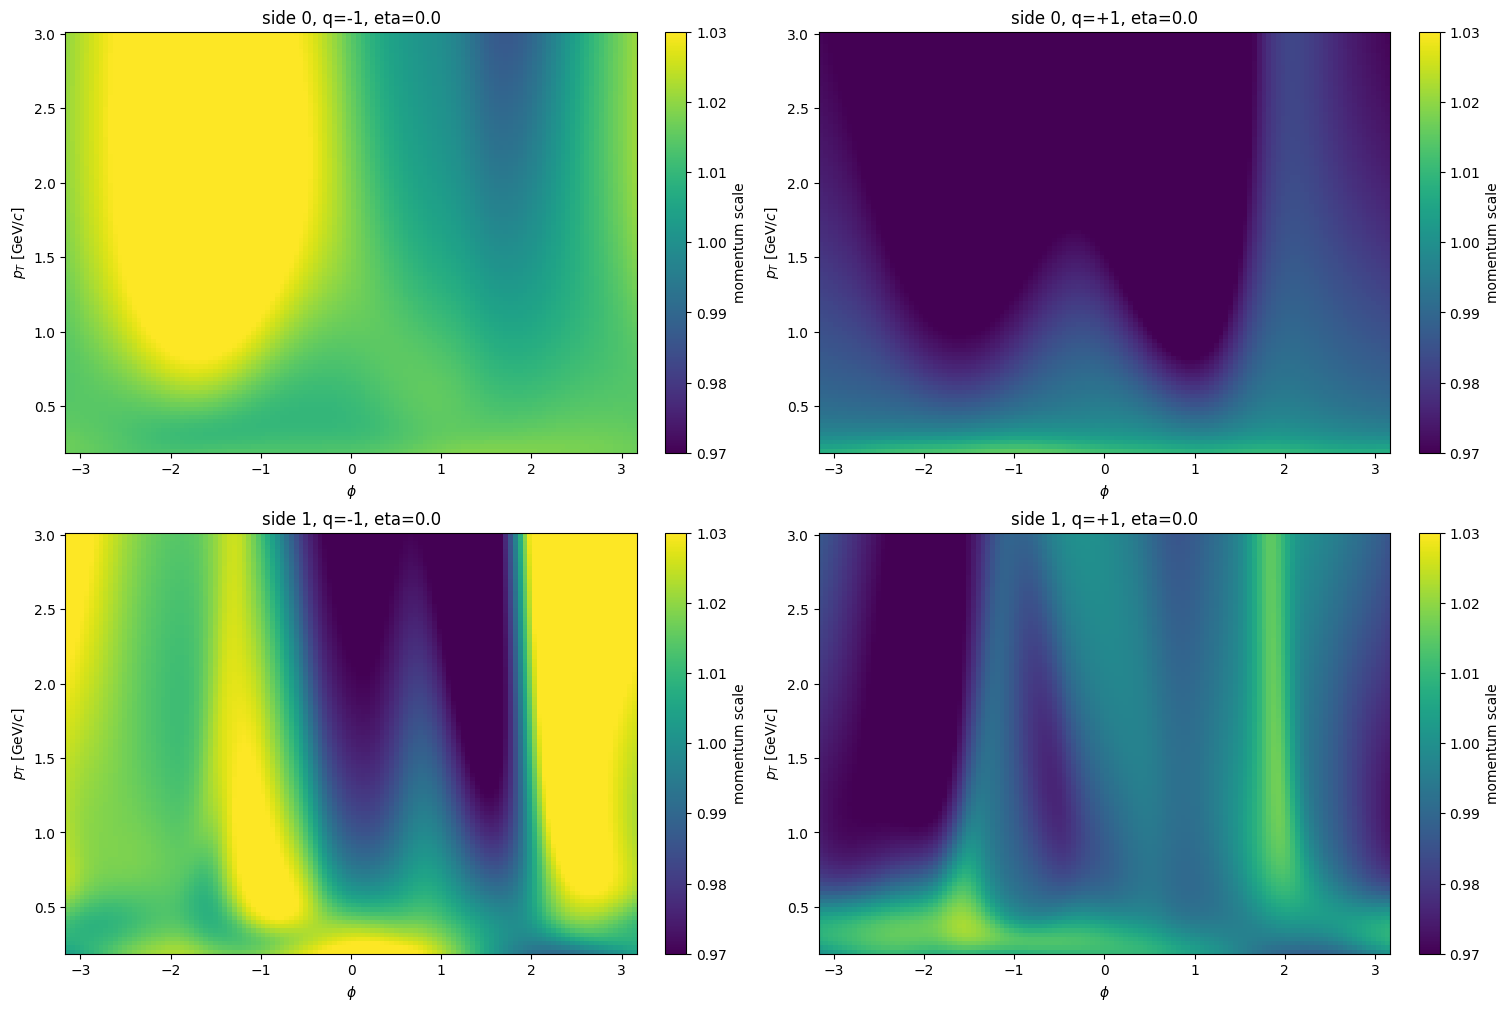

In [16]:
# ============================================================
# Inspect pT-phi maps at fixed eta
# ============================================================

display_eta = 0.0

pt_display = np.linspace(
    0.20,
    3.00,
    100,
)

phi_display = np.linspace(
    -math.pi,
    math.pi,
    120,
)

pt_mesh, phi_mesh = np.meshgrid(
    pt_display,
    phi_display,
    indexing="ij",
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    constrained_layout=True,
)

for side in [0, 1]:
    for charge_index, charge in enumerate(
        [-1, 1]
    ):
        statistics = (
            ensemble_scale_statistics(
                side=side,
                charge=np.full(
                    pt_mesh.size,
                    charge,
                    dtype=np.float32,
                ),
                pt=pt_mesh.ravel(),
                phi=phi_mesh.ravel(),
                eta=np.full(
                    pt_mesh.size,
                    display_eta,
                    dtype=np.float32,
                ),
            )
        )

        scale = statistics[
            "mean"
        ].reshape(pt_mesh.shape)

        axis = axes[
            side,
            charge_index,
        ]

        image = axis.pcolormesh(
            phi_display,
            pt_display,
            scale,
            shading="auto",
            vmin=0.97,
            vmax=1.03,
        )

        axis.set_xlabel(r"$\phi$")
        axis.set_ylabel(
            r"$p_T$ [GeV/$c$]"
        )

        axis.set_title(
            f"side {side}, q={charge:+d}, "
            f"eta={display_eta:.1f}"
        )

        figure.colorbar(
            image,
            ax=axis,
            label="momentum scale",
        )

plt.show()


In [17]:
# ============================================================
# Evaluate and save the final map grid
# ============================================================

pt_edges = np.array([
    0.20,
    0.30,
    0.40,
    0.55,
    0.70,
    0.90,
    1.20,
    1.50,
    2.00,
    3.00,
    5.00,
], dtype=np.float64)

phi_edges = np.linspace(
    -math.pi,
    math.pi,
    25,
    dtype=np.float64,
)

eta_edges = np.linspace(
    -1.10,
    1.10,
    12,
    dtype=np.float64,
)

pt_centers = 0.5 * (
    pt_edges[:-1]
    + pt_edges[1:]
)

phi_centers = 0.5 * (
    phi_edges[:-1]
    + phi_edges[1:]
)

eta_centers = 0.5 * (
    eta_edges[:-1]
    + eta_edges[1:]
)

grid_rows = []

for side in [0, 1]:
    for charge in [-1, 1]:
        pt_grid, phi_grid, eta_grid = (
            np.meshgrid(
                pt_centers,
                phi_centers,
                eta_centers,
                indexing="ij",
            )
        )

        statistics = (
            ensemble_scale_statistics(
                side=side,
                charge=np.full(
                    pt_grid.size,
                    charge,
                    dtype=np.float32,
                ),
                pt=pt_grid.ravel(),
                phi=phi_grid.ravel(),
                eta=eta_grid.ravel(),
            )
        )

        for (
            pt,
            phi,
            eta,
            scale,
            scale_std,
        ) in zip(
            pt_grid.ravel(),
            phi_grid.ravel(),
            eta_grid.ravel(),
            statistics["mean"],
            statistics["std"],
        ):
            grid_rows.append({
                "side": side,
                "charge": charge,
                "pt": pt,
                "phi": phi,
                "eta": eta,
                "momentum_scale": scale,
                "ensemble_scale_std": scale_std,
            })

map_grid = pd.DataFrame(
    grid_rows
)

map_grid.to_csv(
    map_csv_file,
    index=False,
)

print("Wrote:", map_csv_file)

display(
    map_grid.groupby(
        ["side", "charge"]
    )[
        [
            "momentum_scale",
            "ensemble_scale_std",
        ]
    ].agg(
        ["min", "max", "mean", "std"]
    )
)


Wrote: output/k0s_momentum_scale_map_plots_cut03/k0s_dnn_momentum_scale_grid.csv


momentum_scale                               ensemble_scale_std  \
                       min       max      mean       std                min   
side charge                                                                   
0    -1           0.938727  1.037252  1.005905  0.021991           0.000042   
      1           0.932394  1.058788  0.983718  0.023152           0.000000   
1    -1           0.939356  1.064420  1.008204  0.028712           0.000132   
      1           0.948097  1.036190  0.997711  0.013903           0.000055   

                                           
                  max      mean       std  
side charge                                
0    -1      0.028533  0.003802  0.002927  
      1      0.031001  0.004321  0.003599  
1    -1      0.048083  0.007354  0.007153  
      1      0.032234  0.005447  0.004523

In [18]:
# ============================================================
# Write ROOT maps compatible with the application macro
# ============================================================

if root is None:
    print(
        "PyROOT is unavailable. "
        "The map-grid CSV was written, "
        "but the ROOT map was not."
    )
else:
    output = root.TFile.Open(
        str(map_root_file),
        "RECREATE",
    )

    if not output or output.IsZombie():
        raise OSError(
            f"Could not create "
            f"{map_root_file}"
        )

    root.TNamed(
        "method",
        (
            "parallel grid-searched weakly supervised "
            "charge-even/charge-odd DNN; "
            f"training parity={training_parity}; "
            f"validation parity={validation_parity}; "
            f"ensemble models={number_of_ensemble_models}"
        ),
    ).Write()

    root.TNamed(
        "best_hyperparameters_json",
        json.dumps(
            {
                str(side): configuration
                for side, configuration
                in best_configurations.items()
            }
        ),
    ).Write()

    for side in [0, 1]:
        side_directory = output.mkdir(
            f"side{side}"
        )

        for charge in [-1, 1]:
            charge_directory = (
                side_directory.mkdir(
                    "qplus"
                    if charge > 0
                    else "qminus"
                )
            )

            charge_directory.cd()

            scale_histogram = root.TH3D(
                "h3_momentum_scale",
                (
                    "DNN momentum scale;"
                    "p_{T} [GeV/c];#phi;#eta"
                ),
                len(pt_edges) - 1,
                array("d", pt_edges),
                len(phi_edges) - 1,
                array("d", phi_edges),
                len(eta_edges) - 1,
                array("d", eta_edges),
            )

            uncertainty_histogram = root.TH3D(
                "h3_momentum_scale_ensemble_std",
                (
                    "DNN ensemble scale spread;"
                    "p_{T} [GeV/c];#phi;#eta"
                ),
                len(pt_edges) - 1,
                array("d", pt_edges),
                len(phi_edges) - 1,
                array("d", phi_edges),
                len(eta_edges) - 1,
                array("d", eta_edges),
            )

            subset = map_grid.loc[
                (map_grid["side"] == side)
                & (
                    map_grid["charge"]
                    == charge
                )
            ]

            for row in subset.itertuples(
                index=False
            ):
                pt_bin = (
                    scale_histogram
                    .GetXaxis()
                    .FindBin(row.pt)
                )

                phi_bin = (
                    scale_histogram
                    .GetYaxis()
                    .FindBin(row.phi)
                )

                eta_bin = (
                    scale_histogram
                    .GetZaxis()
                    .FindBin(row.eta)
                )

                scale_histogram.SetBinContent(
                    pt_bin,
                    phi_bin,
                    eta_bin,
                    float(
                        row.momentum_scale
                    ),
                )

                uncertainty_histogram.SetBinContent(
                    pt_bin,
                    phi_bin,
                    eta_bin,
                    float(
                        row.ensemble_scale_std
                    ),
                )

            scale_histogram.Write()
            uncertainty_histogram.Write()

    output.Close()

    print("Wrote:", map_root_file)


Wrote: output/k0s_momentum_scale_map_plots_cut03/k0s_dnn_momentum_scale_map1.root


## Practical use

For an initial test:

```python
requested_cpus = 12
search_mode = "random"
maximum_trials_per_side = 36
```

This runs 72 side-specific trials in total, with up to 12 trials at the same time.

For a broader search:

```python
requested_cpus = 24
maximum_trials_per_side = 100
```

The number of simultaneous processes is limited by `os.cpu_count()`.

Do not choose the best configuration from training loss. The notebook ranks trials using the untouched validation sample, including:

- validation mass likelihood;
- distance of the validation peak from the PDG mass;
- penalty when the validation width becomes worse;
- penalty when many predictions sit at the allowed correction boundary.

After a satisfactory result, reverse the split:

```python
training_parity = 1
validation_parity = 0
```

and require the independently learned maps to agree.
